In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Consistent style across all notebooks in this series
sns.set_theme(
    style='whitegrid',
    palette='muted',
    rc={
        'figure.figsize': (12, 6),
        'font.size': 12,
        'axes.titlesize': 14,
    }
)

COLORS = {'Absence': '#3498db', 'Presence': '#e74c3c'}
RANDOM_STATE = 42

train = pd.read_csv('train.csv')
print(f"Data: {train.shape}")

Data: (630000, 15)


In [2]:
print("=== Shape ===")
print(f"Train: {train.shape[0]:,} rows × {train.shape[1]} columns")

print("=== Data Types ===")
print(train.dtypes.to_string())

print("\n=== Numeric Features — Statistical Summary ===")
display(train.describe().round(2))

print("\n=== Target Variable ===")
display(train[['Heart Disease']].describe())

=== Shape ===
Train: 630,000 rows × 15 columns
=== Data Types ===
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object

=== Numeric Features — Statistical Summary ===


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00
mean,314999.50,54.14,0.71,3.31,130.50,245.01,0.08,0.98,152.82,0.27,0.72,1.46,0.45,4.62
std,181865.48,8.26,0.45,0.85,14.98,33.68,0.27,1.00,19.11,0.45,0.95,0.55,0.80,1.95
min,0.00,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,157499.75,48.00,0.00,3.00,120.00,223.00,0.00,0.00,142.00,0.00,0.00,1.00,0.00,3.00
50%,314999.50,54.00,1.00,4.00,130.00,243.00,0.00,0.00,157.00,0.00,0.10,1.00,0.00,3.00
75%,472499.25,60.00,1.00,4.00,140.00,269.00,0.00,2.00,166.00,1.00,1.40,2.00,1.00,7.00
max,629999.00,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00



=== Target Variable ===


,Heart Disease
count,630000
unique,2
top,Absence
freq,347546


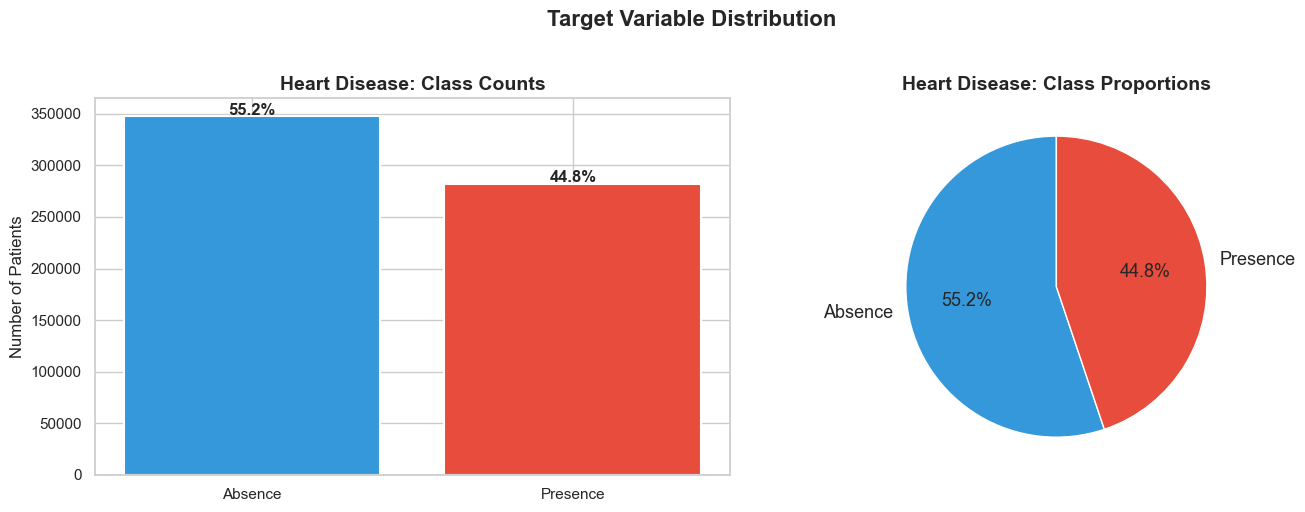

Class balance: 44.8% Presence | 55.2% Absence


In [3]:
target_counts = train['Heart Disease'].value_counts()
target_pct    = train['Heart Disease'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=[COLORS[k] for k in target_counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Heart Disease: Class Counts', fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{pct:.1f}%', ha='center', fontweight='bold')
# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            colors=[COLORS[k] for k in target_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Heart Disease: Class Proportions', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Class balance: {target_pct['Presence']:.1f}% Presence | {target_pct['Absence']:.1f}% Absence")

In [4]:
# Đếm số lượng giá trị khuyết trên mỗi cột
train.isna().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

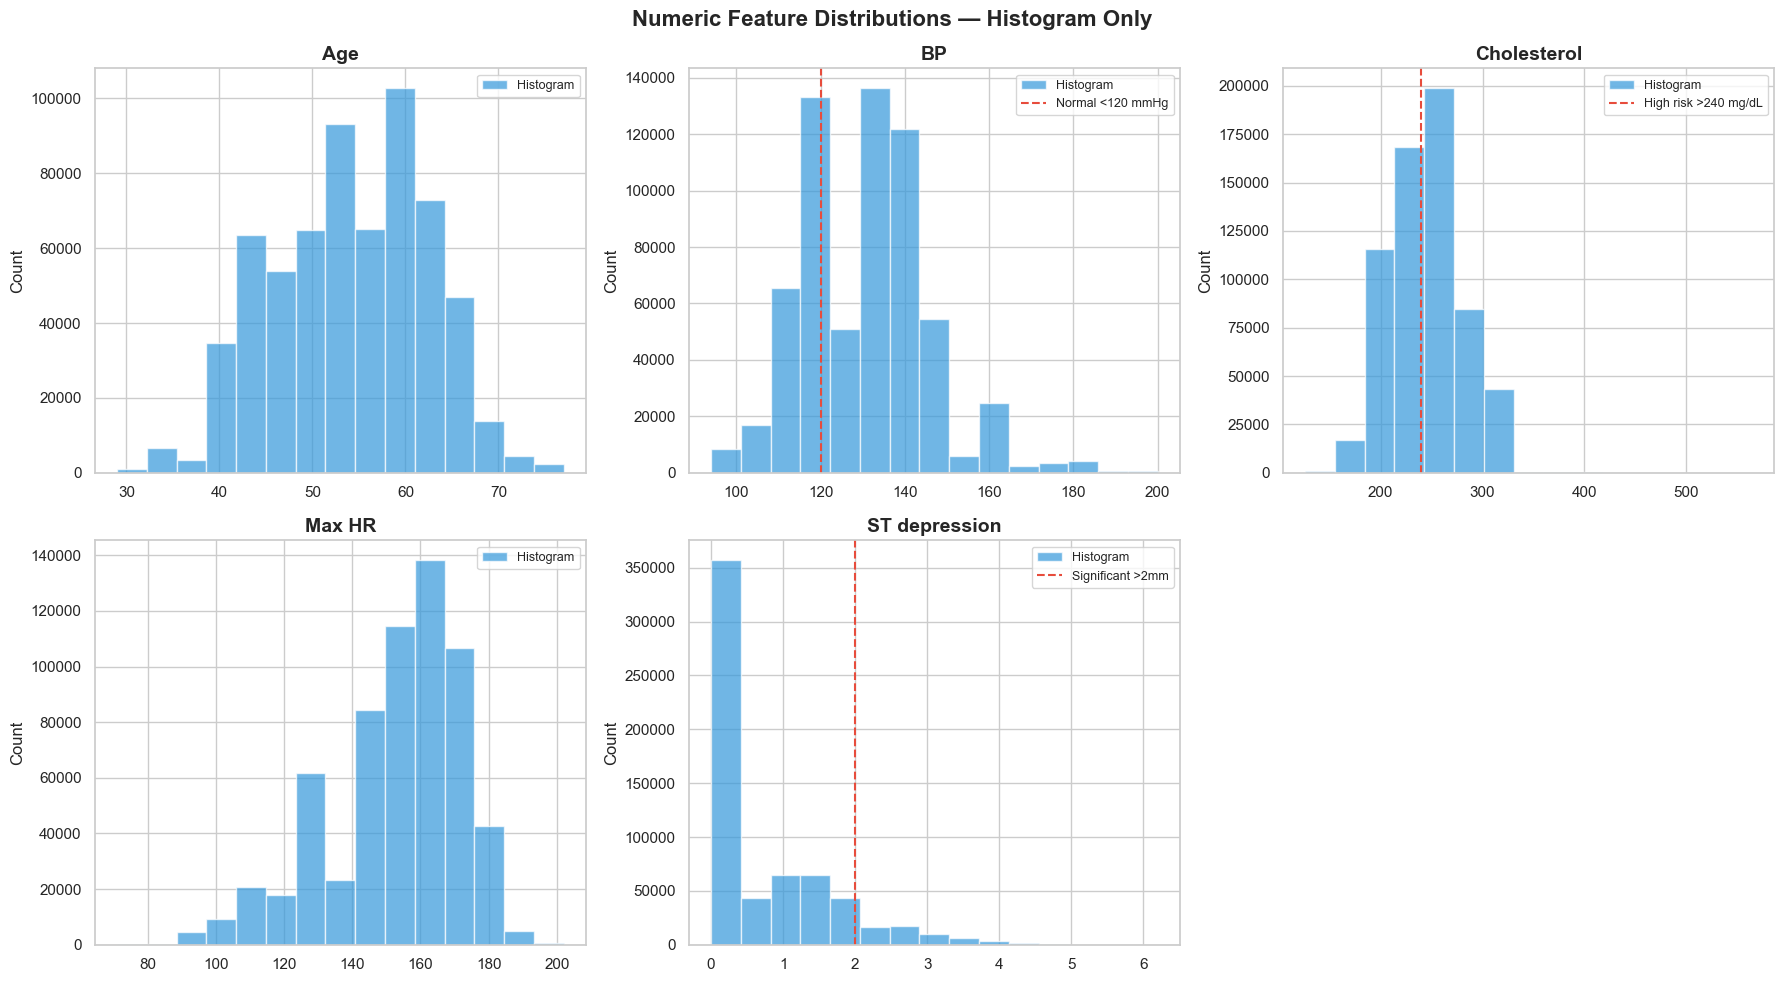

In [5]:
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
clinical_refs = {
    'BP':           (120,  'Normal <120 mmHg'),
    'Cholesterol':  (240,  'High risk >240 mg/dL'),
    'ST depression':(2,    'Significant >2mm'),
    'Age':          (None, None),
    'Max HR':       (None, None),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Chỉ giữ lại hàm vẽ Histogram. 
    # Mẹo: Bỏ tham số 'density=True' để trục Y hiển thị số lượng bệnh nhân thực tế (Count) thay vì tần suất (Density).
    # Tôi cũng tăng alpha=0.7 để cột màu xanh nhìn rõ nét hơn khi không có đường KDE đè lên.
    ax.hist(train[col].dropna(), bins=15, color=COLORS['Absence'], alpha=0.7, label='Histogram')
    
    # (Đã xóa dòng lệnh vẽ KDE tại đây)
    
    ref_val, ref_label = clinical_refs[col]
    if ref_val is not None:
        ax.axvline(ref_val, color=COLORS['Presence'], linestyle='--', linewidth=1.5, label=ref_label)
        
    ax.set_title(col, fontweight='bold')
    
    # Đổi nhãn trục Y thành 'Count' (Số lượng) vì chúng ta không còn dùng Density nữa
    ax.set_ylabel('Count') 
    ax.legend(fontsize=9)

axes[-1].set_visible(False)

# Cập nhật lại tiêu đề tổng cho phù hợp
plt.suptitle('Numeric Feature Distributions — Histogram Only', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

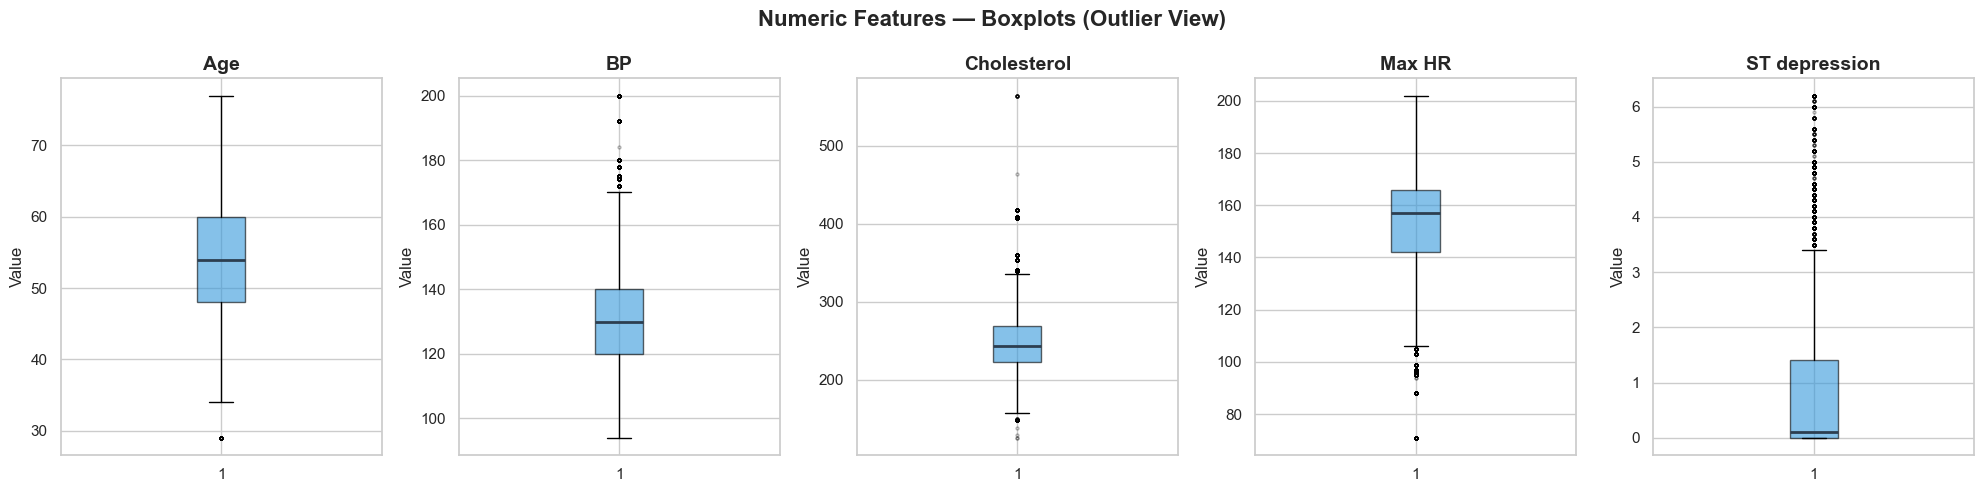

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=COLORS['Absence'], alpha=0.6),
                    medianprops=dict(color='#2c3e50', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Numeric Features — Boxplots (Outlier View)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

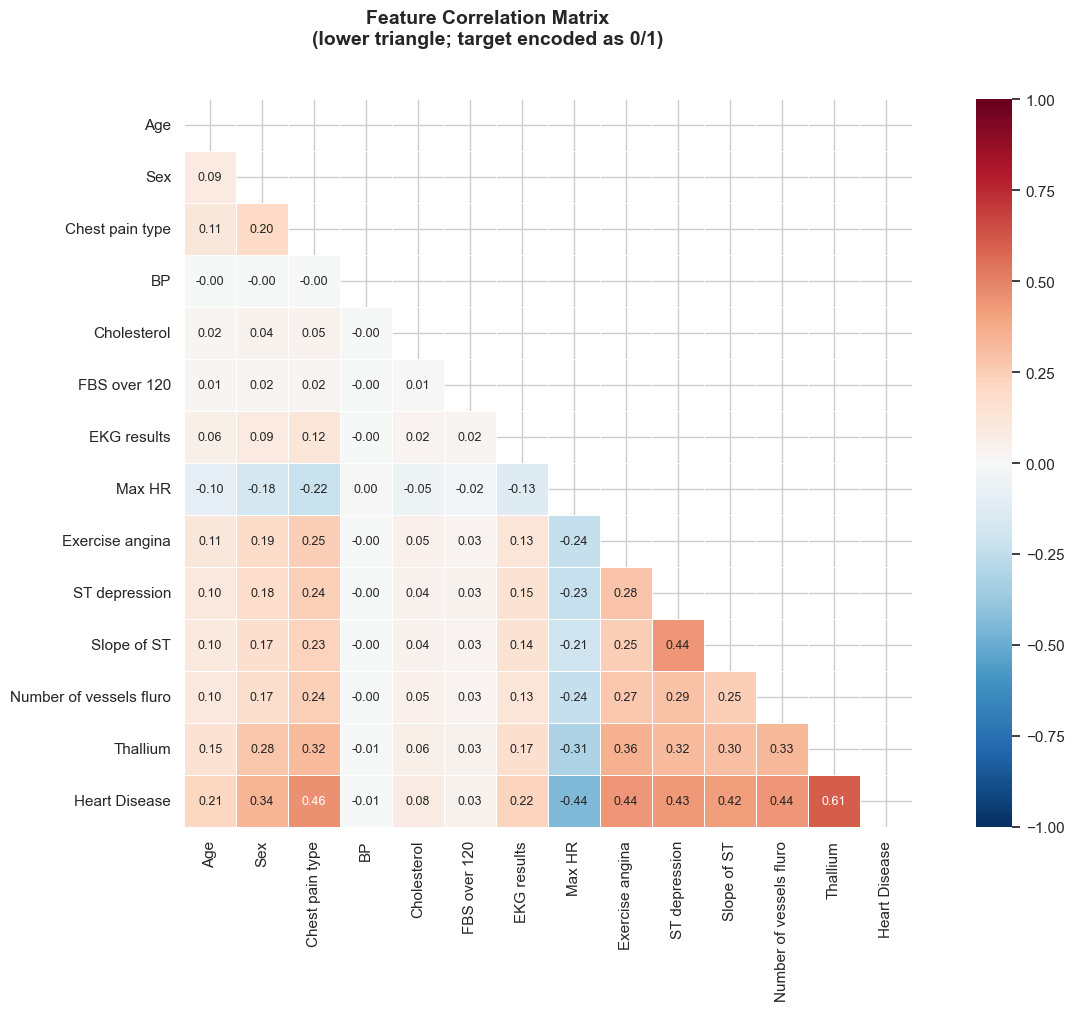

Features ranked by |correlation| with target:
Thallium                   0.606
Chest pain type            0.461
Exercise angina            0.442
Max HR                     0.441
Number of vessels fluro    0.439
ST depression              0.431
Slope of ST                0.415
Sex                        0.342
EKG results                0.219
Age                        0.212
Cholesterol                0.083
FBS over 120               0.034
BP                         0.005


In [7]:
train_enc = train.copy()
train_enc['Heart Disease'] = (train_enc['Heart Disease'] == 'Presence').astype(int)
corr = train_enc.drop('id', axis=1).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.suptitle('Feature Correlation Matrix\n(lower triangle; target encoded as 0/1)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['Heart Disease'].drop('Heart Disease').abs().sort_values(ascending=False)
print("Features ranked by |correlation| with target:")
print(target_corr.round(3).to_string())

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(
    style='whitegrid',
    palette='muted',
    rc={
        'figure.figsize': (12, 6),
        'font.size': 12,
        'axes.titlesize': 14,
    }
)

COLORS = {'Absence': '#3498db', 'Presence': '#e74c3c'}
RANDOM_STATE = 42

train = pd.read_csv('train.csv')
# test  = pd.read_csv('test.csv')

train['target'] = (train['Heart Disease'] == 'Presence').astype(int)
print(f"Data: {train.shape}")

Data: (630000, 16)


Columns with actual missing values: None


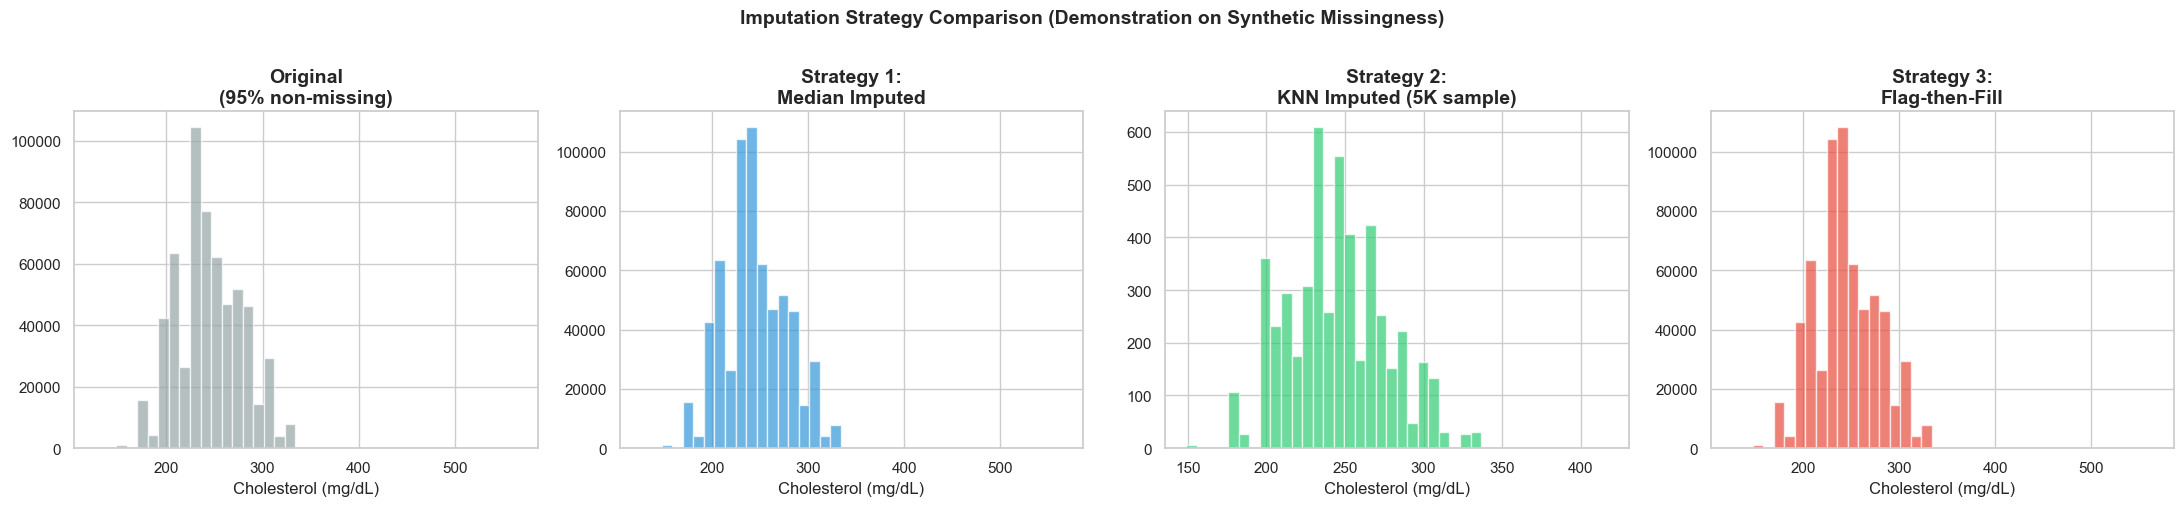


For this dataset: we apply median imputation (fast, effective for near-complete data).
Strategies 1 and 3 produce nearly identical fill values — the key difference is that
Strategy 3 ALSO adds a binary '_was_missing' column. Tree models like XGBoost and
LightGBM can then split on 'was this test result missing?' as a feature in its own right.


In [10]:
missing_cols = [col for col in train.columns if train[col].isnull().any()]
print(f"Columns with actual missing values: {missing_cols if missing_cols else 'None'}")

# Demonstrate on synthetically introduced missingness in Cholesterol (5% missing)
demo = train.copy()
np.random.seed(RANDOM_STATE)
mask = np.random.rand(len(demo)) < 0.05
demo.loc[mask, 'Cholesterol'] = np.nan

# Strategy 1: Median imputation
median_filled = demo['Cholesterol'].fillna(demo['Cholesterol'].median())

# Strategy 2: KNN imputation (5 000-row sample — KNN is O(n^2), impractical on 630 K rows)
knn_demo = demo[['Age', 'BP', 'Cholesterol', 'Max HR']].sample(5000, random_state=RANDOM_STATE)
knn = KNNImputer(n_neighbors=5)
knn_array = knn.fit_transform(knn_demo)
knn_chol = knn_array[:, 2]

# Strategy 3: Flag-then-fill
demo['cholesterol_was_missing'] = mask.astype(int)
flag_filled = demo['Cholesterol'].fillna(demo['Cholesterol'].median())

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, vals, title, color in zip(
    axes,
    [demo['Cholesterol'].dropna(), median_filled, pd.Series(knn_chol), flag_filled],
    ['Original\n(95% non-missing)', 'Strategy 1:\nMedian Imputed',
     'Strategy 2:\nKNN Imputed (5K sample)', 'Strategy 3:\nFlag-then-Fill'],
    ['#95a5a6', COLORS['Absence'], '#2ecc71', COLORS['Presence']]
):
    ax.hist(vals, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cholesterol (mg/dL)')

plt.suptitle('Imputation Strategy Comparison (Demonstration on Synthetic Missingness)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nFor this dataset: we apply median imputation (fast, effective for near-complete data).")
print("Strategies 1 and 3 produce nearly identical fill values — the key difference is that")
print("Strategy 3 ALSO adds a binary '_was_missing' column. Tree models like XGBoost and")
print("LightGBM can then split on 'was this test result missing?' as a feature in its own right.")

In [11]:
train_fe = train.copy().drop('Heart Disease', axis=1)
# test_fe  = test.copy()

# Remap Thallium: 3→0, 6→1, 7→2 (nominal values → ordinal 0-indexed for tree models)
for df in [train_fe]:
    df['Thallium'] = df['Thallium'].map({3: 0, 6: 1, 7: 2})

cat_notes = {
    'Sex':                     'Binary (0=F, 1=M) — already encoded',
    'Chest pain type':         'Ordinal 1–4 — retained as-is',
    'FBS over 120':            'Binary (0/1) — already encoded',
    'EKG results':             'Ordinal 0–2 — retained as-is',
    'Exercise angina':         'Binary (0/1) — already encoded',
    'Slope of ST':             'Ordinal 1–3 — retained as-is',
    'Number of vessels fluro': 'Ordinal 0–3 — retained as-is',
    'Thallium':                'Nominal (3/6/7) → remapped to 0/1/2 for model compatibility',
}

print("Encoding decisions:")
for col, note in cat_notes.items():
    print(f"  {col}: {note}")

Encoding decisions:
  Sex: Binary (0=F, 1=M) — already encoded
  Chest pain type: Ordinal 1–4 — retained as-is
  FBS over 120: Binary (0/1) — already encoded
  EKG results: Ordinal 0–2 — retained as-is
  Exercise angina: Binary (0/1) — already encoded
  Slope of ST: Ordinal 1–3 — retained as-is
  Number of vessels fluro: Ordinal 0–3 — retained as-is
  Thallium: Nominal (3/6/7) → remapped to 0/1/2 for model compatibility


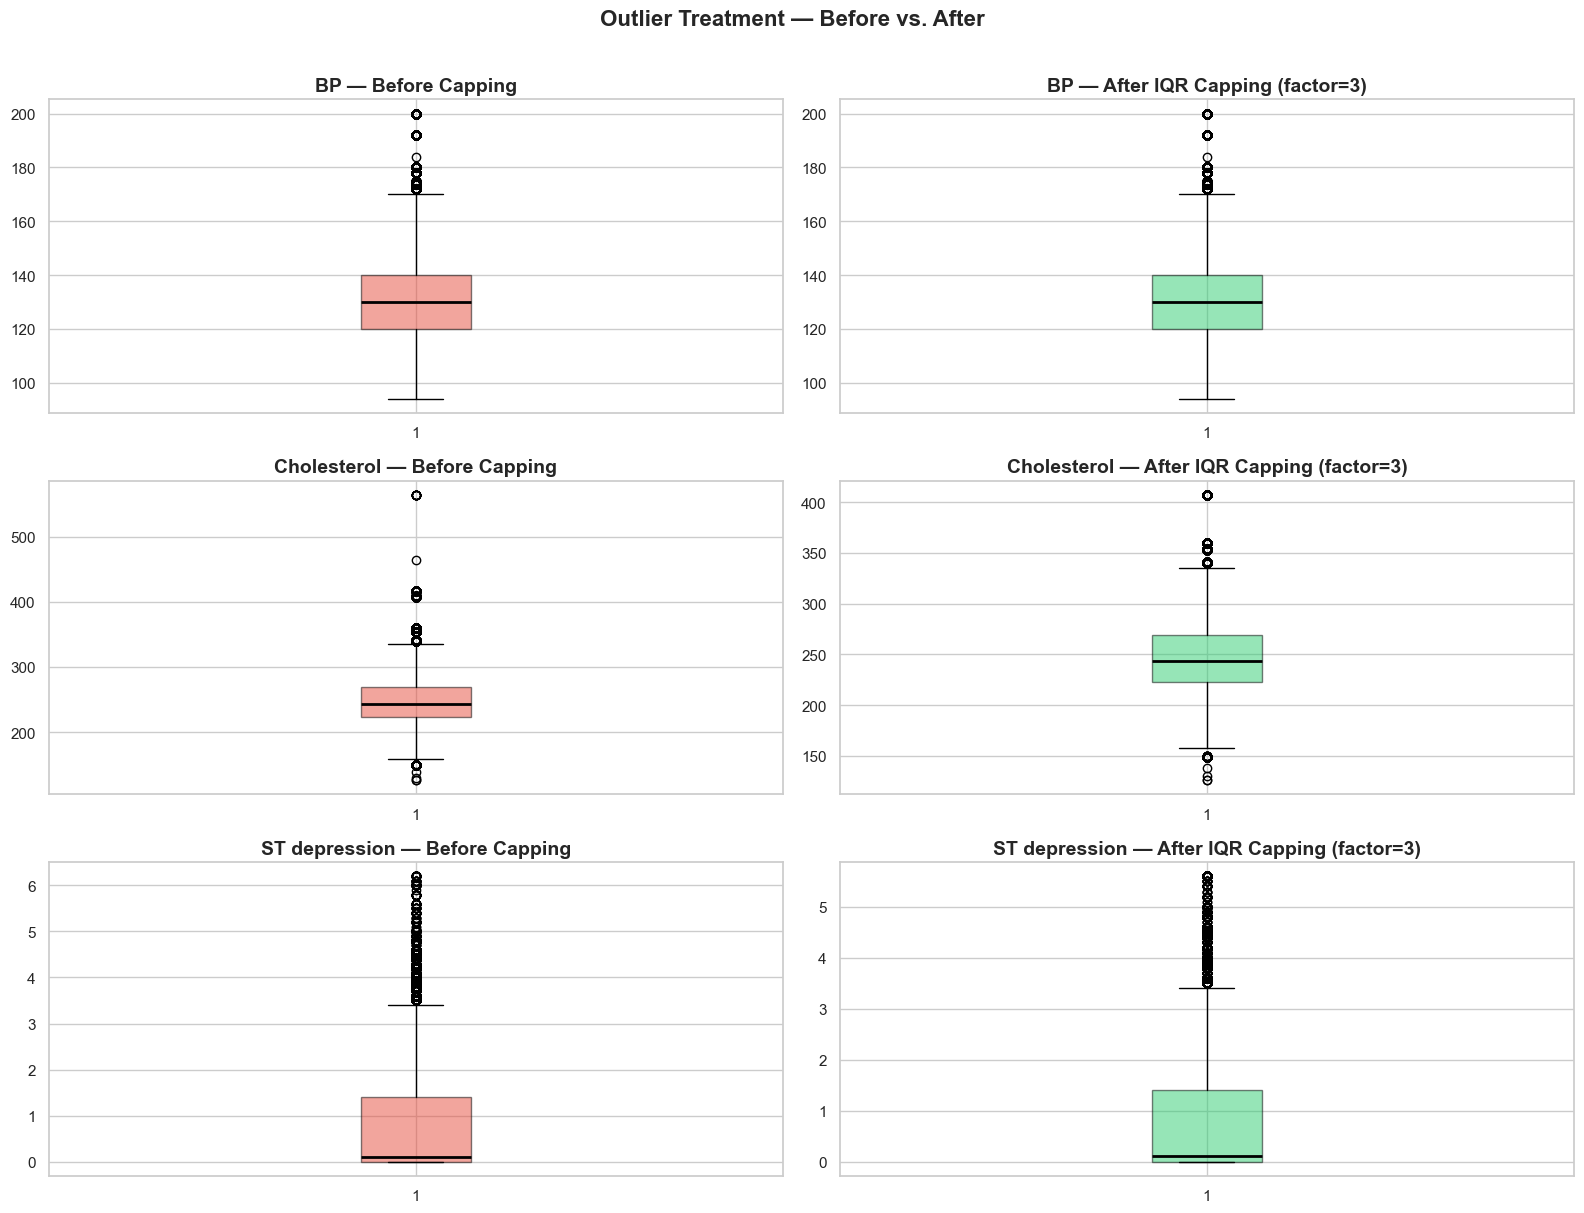

In [13]:
def iqr_cap(series, factor=3.0):
    """Cap values at Q1 - factor*IQR and Q3 + factor*IQR."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lo, hi), lo, hi

outlier_cols = ['BP', 'Cholesterol', 'ST depression']
fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(16, 4*len(outlier_cols)))

for i, col in enumerate(outlier_cols):
    original = train_fe[col].copy()
    capped, lo, hi = iqr_cap(train_fe[col])
    train_fe[col] = capped
    # test_fe[col]  = test_fe[col].clip(lo, hi)

    axes[i, 0].boxplot(original, patch_artist=True,
                       boxprops=dict(facecolor=COLORS['Presence'], alpha=0.5),
                       medianprops=dict(color='black', linewidth=2))
    axes[i, 0].set_title(f'{col} — Before Capping', fontweight='bold')

    axes[i, 1].boxplot(capped, patch_artist=True,
                       boxprops=dict(facecolor='#2ecc71', alpha=0.5),
                       medianprops=dict(color='black', linewidth=2))
    axes[i, 1].set_title(f'{col} — After IQR Capping (factor=3)', fontweight='bold')

plt.suptitle('Outlier Treatment — Before vs. After', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
for df in [train_fe]:
    # 1. Age risk bucket — standard cardiovascular risk thresholds
    df['age_risk'] = pd.cut(df['Age'], bins=[0, 40, 55, 65, 120],
                            labels=[0, 1, 2, 3]).astype(int)

    # 2. BP × Cholesterol interaction — combined cardiovascular burden score
    df['bp_chol_interaction'] = df['BP'] * df['Cholesterol'] / 10000

    # 3. HR reserve ratio — achieved HR as % of age-predicted max (220 - Age)
    #    Low ratio = heart cannot respond to exercise demand = poor cardiac function
    df['hr_reserve_ratio'] = df['Max HR'] / (220 - df['Age'])
    
    # 4. Exercise stress score — ST depression normalized by HR reserve
    #    High ST depression + low HR reserve = severe ischemia under exercise
    df['stress_score'] = df['ST depression'] / (df['hr_reserve_ratio'] + 1e-6)

    # 5. Silent ischemia flag — asymptomatic chest pain with exercise-induced angina
    #    This combination is a red flag: no symptoms at rest but clear ischemia under load
    df['silent_ischemia_flag'] = (
        (df['Chest pain type'] == 4) & (df['Exercise angina'] == 1)
    ).astype(int)
    
new_features = ['age_risk', 'bp_chol_interaction', 'hr_reserve_ratio',
                'stress_score', 'silent_ischemia_flag']

print("New features created:")
display(train_fe[new_features].describe().round(3))

New features created:


,age_risk,bp_chol_interaction,hr_reserve_ratio,stress_score,silent_ischemia_flag
count,630000.000,630000.000,630000.000,630000.000,630000.000
mean,1.518,3.197,0.923,0.819,0.206
std,0.690,0.573,0.121,1.118,0.404
min,0.000,1.401,0.384,0.000,0.000
25%,1.000,2.789,0.852,0.000,0.000
50%,1.000,3.159,0.938,0.087,0.000
75%,2.000,3.556,1.006,1.491,0.000
max,3.000,8.140,1.356,10.952,1.000


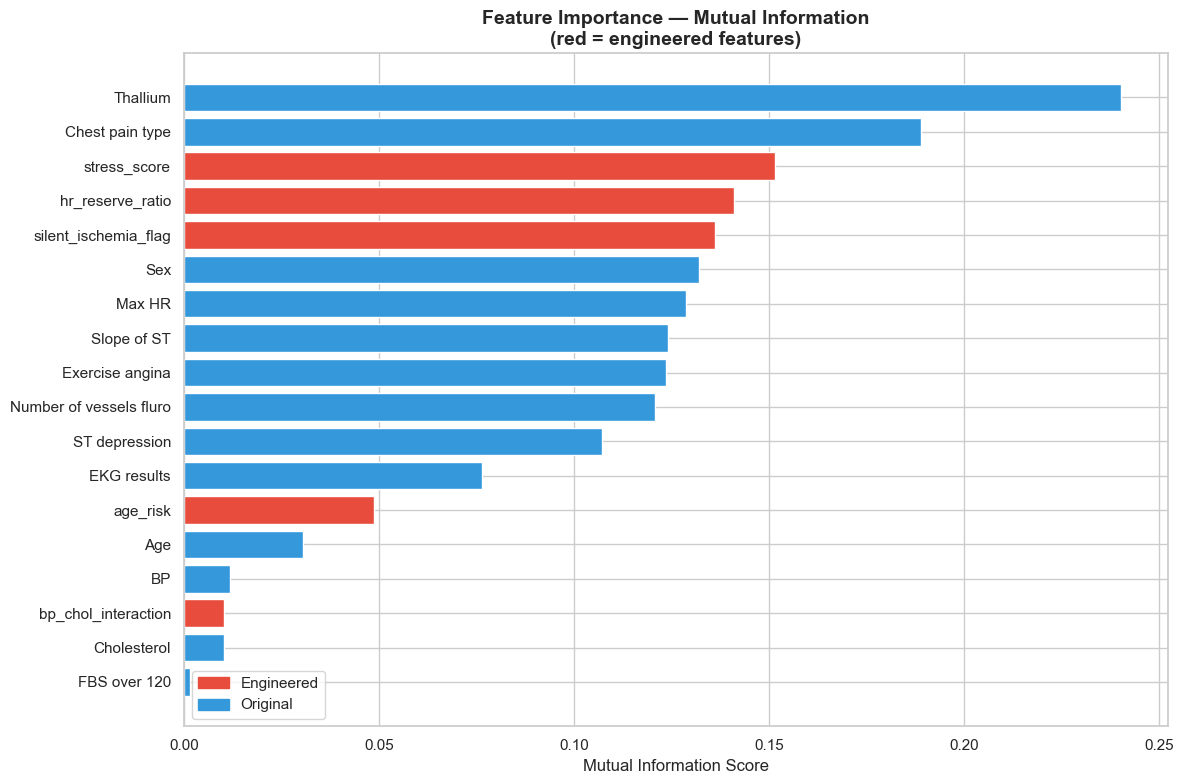

In [16]:
feature_cols = [c for c in train_fe.columns if c not in ['id', 'target']]
X = train_fe[feature_cols].fillna(0)
y = train_fe['target']

mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE) # hàm dùng để sắp xếp mức độ quan trọng của các thuộc tính
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [COLORS['Presence'] if f in new_features else COLORS['Absence']
          for f in mi_df['Feature']]
ax.barh(mi_df['Feature'], mi_df['MI Score'], color=colors, edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance — Mutual Information\n(red = engineered features)',
             fontweight='bold')
ax.invert_yaxis()
ax.legend(handles=[mpatches.Patch(color=COLORS['Presence'], label='Engineered'),
                   mpatches.Patch(color=COLORS['Absence'],  label='Original')])
plt.tight_layout()
plt.show()


In [17]:
train_fe.to_csv('train_processed.csv', index=False)
# test_fe.to_csv('test_processed.csv', index=False)
print(f"Saved train_processed.csv: {train_fe.shape}")
# print(f"Saved test_processed.csv:  {test_fe.shape}")
feature_cols_saved = [c for c in train_fe.columns if c not in ['id', 'target']]
print(f"\nFeature columns ({len(feature_cols_saved)}): {feature_cols_saved}")
print("\n> Kaggle users: these files appear in this notebook's Output tab.")
print("> Add this notebook's output as a data source in Notebooks 3 and 4.")

Saved train_processed.csv: (630000, 20)

Feature columns (18): ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'age_risk', 'bp_chol_interaction', 'hr_reserve_ratio', 'stress_score', 'silent_ischemia_flag']

> Kaggle users: these files appear in this notebook's Output tab.
> Add this notebook's output as a data source in Notebooks 3 and 4.
